# YOLO Fire Detection Notebook

## Dataset Description

This dataset contains annotated images of fire and smoke and is designed for training object detection models for fire detection and surveillance applications.

### Classes
- **Fire (0):** Images containing visible flames or active fire  
- **Smoke (1):** Images showing smoke or early stages of fire development  

### Dataset Details
- The dataset consists of over 35,000 labeled images  
- Images vary in lighting conditions, resolutions, and environmental settings  
- This variation helps improve the model’s ability to generalize to real-world scenarios  

### Source
The dataset was obtained from Kaggle and is available at:  
https://www.kaggle.com/datasets/roscoekerby/firesmoke-detection-yolo-v9

### GPU Setup

PyTorch was imported to enable GPU acceleration for local model training.

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 5080


## Model Training

### YOLO26n Base Model

In [2]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLO26n model
model = YOLO("yolo26n.pt")

# Train the model on the Fire and Smoke dataset for 100 epochs
results = model.train(data="Fire and Smoke Dataset/data.yaml", epochs=100, imgsz=640, name="yolo26n_base")

New https://pypi.org/project/ultralytics/8.4.33 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.31  Python-3.12.13 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Fire and Smoke Dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, n

#### Results For YOLO26n Base Model

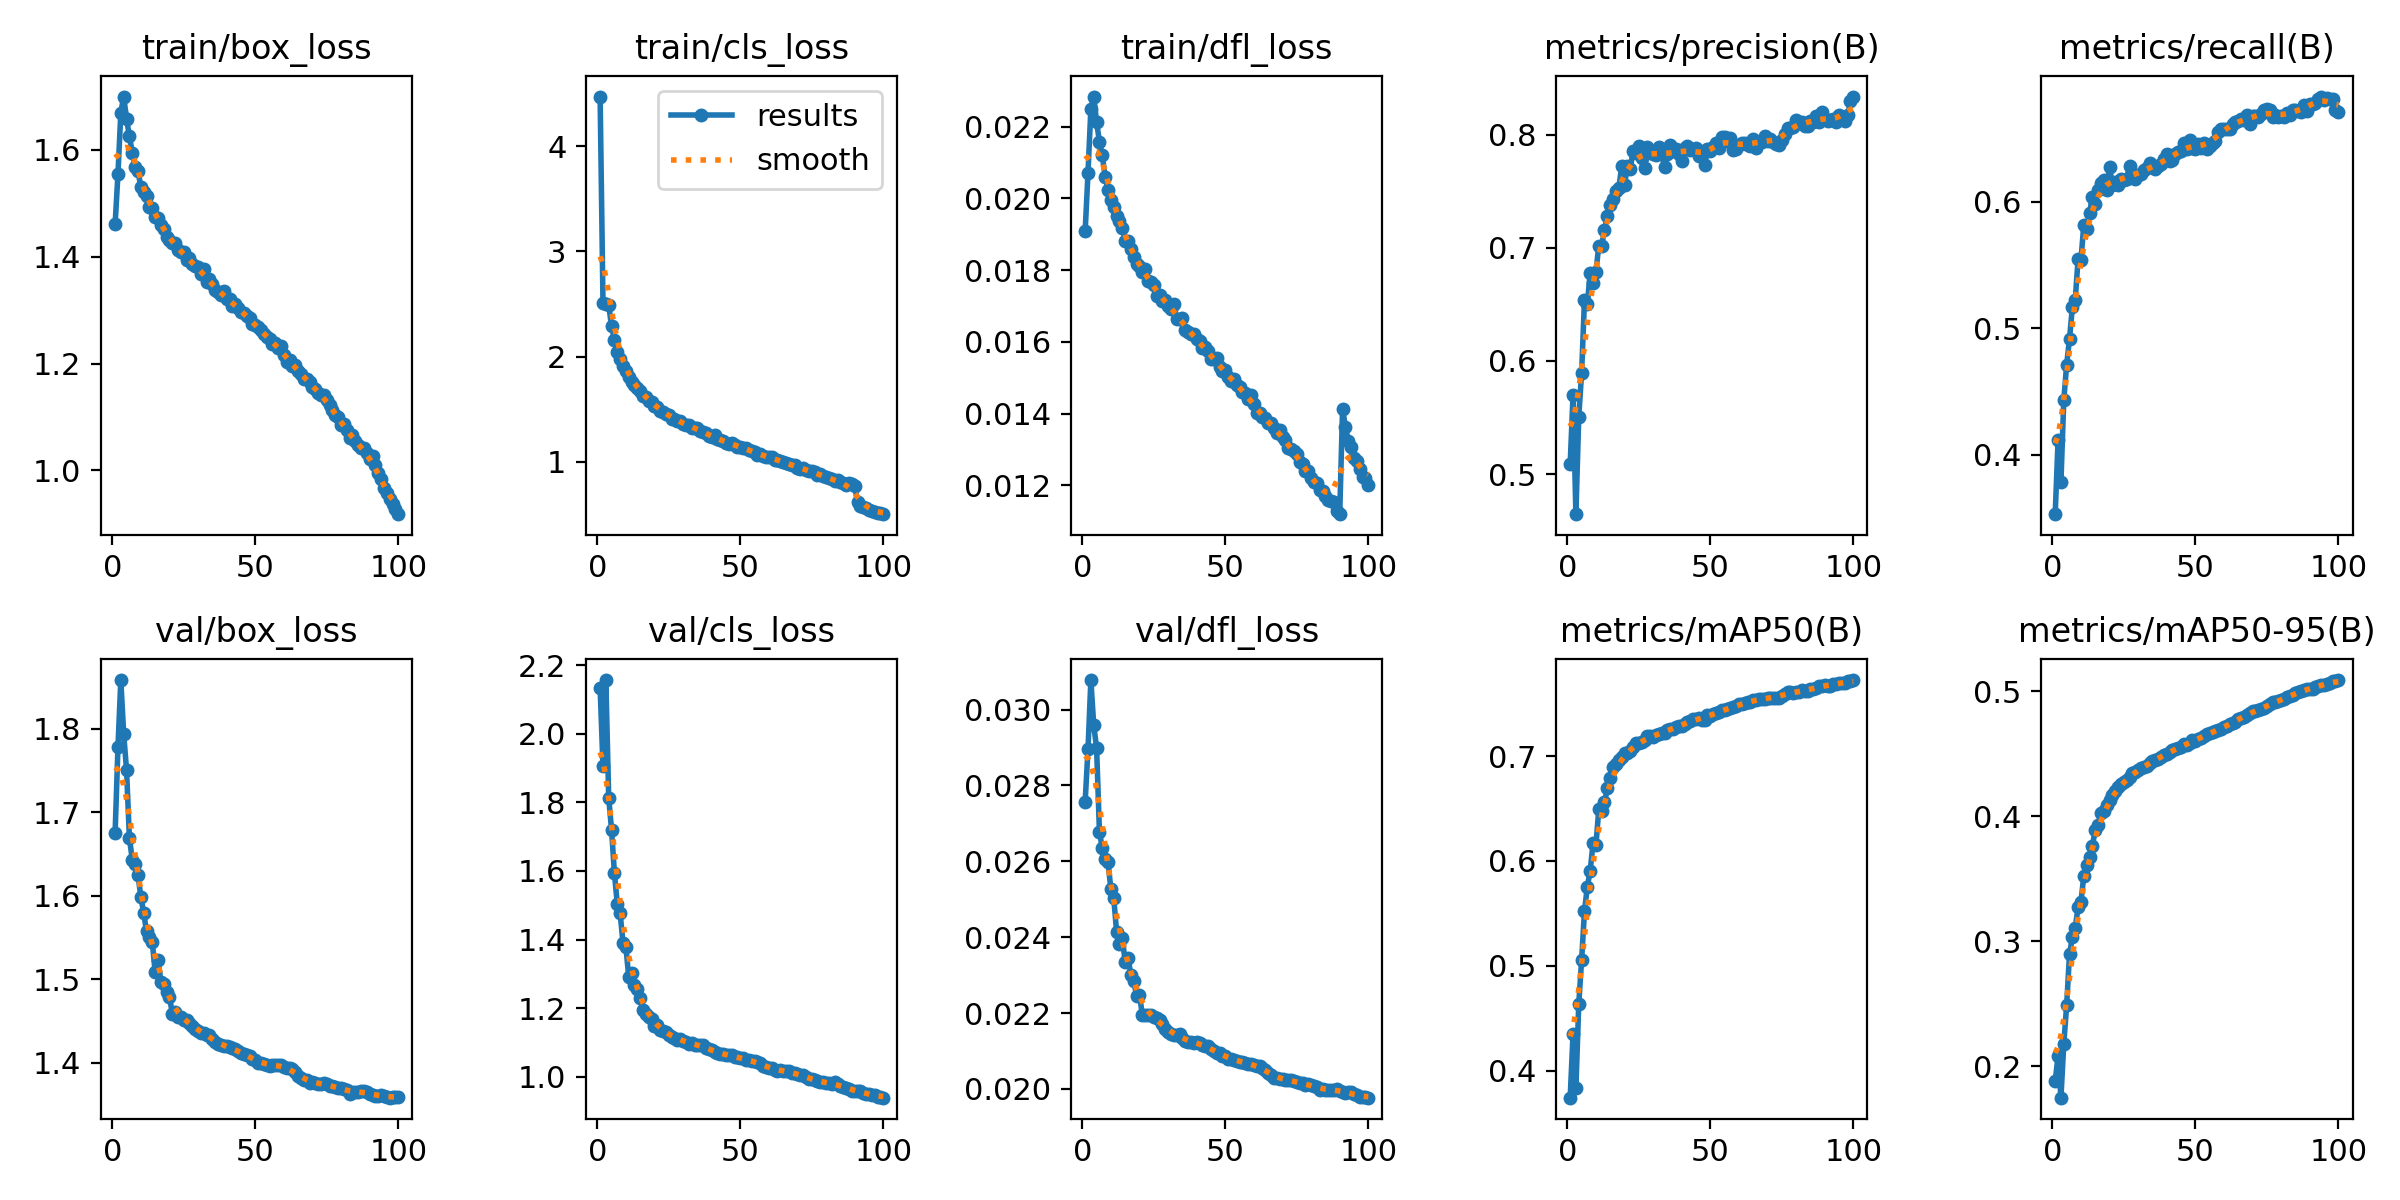

In [4]:
from IPython.display import Image

Image(filename='C:/Users/hjack/OneDrive/Documents/GitHub/Drone-Fire-Detection/runs/detect/yolo26n_base/results.png', width=1000)

### YOLO26n Hyperparameter Tuning

In [ ]:
from ultralytics import YOLO

# Initialize the YOLO model
model = YOLO("yolo26n.pt")

# Define search space
search_space = {
    "lr0": (0.0001, 0.1),
    "momentum": (0.7, 0.98),
    "weight_decay": (0.00005, 0.005),
    "hsv_s": (0.3, 0.9),
    "hsv_v": (0.2, 0.8),
    "scale": (0.3, 0.9)
}

# Tune hyperparameters on the Fire and Smoke dataset for 30 epochs
model.tune(
    data="Fire and Smoke Dataset/data.yaml",
    epochs=30,
    imgsz=640,
    batch=-1,
    optimizer="SGD",
    name="yolo26n_tuned",
    iterations=40,
    space=search_space,
    plots=True,
    save=True,
    val=True,
)

Tuner: Initialized Tuner instance with 'tune_dir=C:\Users\hjack\OneDrive\Documents\GitHub\Drone-Fire-Detection\runs\detect\yolo26n_tuned'
Tuner:  Learn about tuning at https://docs.ultralytics.com/guides/hyperparameter-tuning
Tuner: Starting iteration 1/40 with hyperparameters: {'lr0': 0.01, 'momentum': 0.937, 'weight_decay': 0.0005, 'hsv_s': 0.7, 'hsv_v': 0.4, 'scale': 0.5}
Saved C:\Users\hjack\OneDrive\Documents\GitHub\Drone-Fire-Detection\runs\detect\yolo26n_tuned\tune_scatter_plots.png
Saved C:\Users\hjack\OneDrive\Documents\GitHub\Drone-Fire-Detection\runs\detect\yolo26n_tuned\tune_fitness.png

Tuner: 1/40 iterations complete  (5429.15s)
Tuner: Results saved to C:\Users\hjack\OneDrive\Documents\GitHub\Drone-Fire-Detection\runs\detect\yolo26n_tuned
Tuner: Best fitness=0.47149 observed at iteration 1
Tuner: Best fitness metrics are {'metrics/precision(B)': 0.79301, 'metrics/recall(B)': 0.67406, 'metrics/mAP50(B)': 0.76071, 'metrics/mAP50-95(B)': 0.47149, 'val/box_loss': 1.4502, 'val

#### Best Parameters During Hyperparameter Tuning

- As we see the best iteration was #21, followed by #27 and #13.
- The hyperparameter tuning was evaluation on 30 epochs, so I will test the top 3 iterations to 100 epochs to compare to the base model

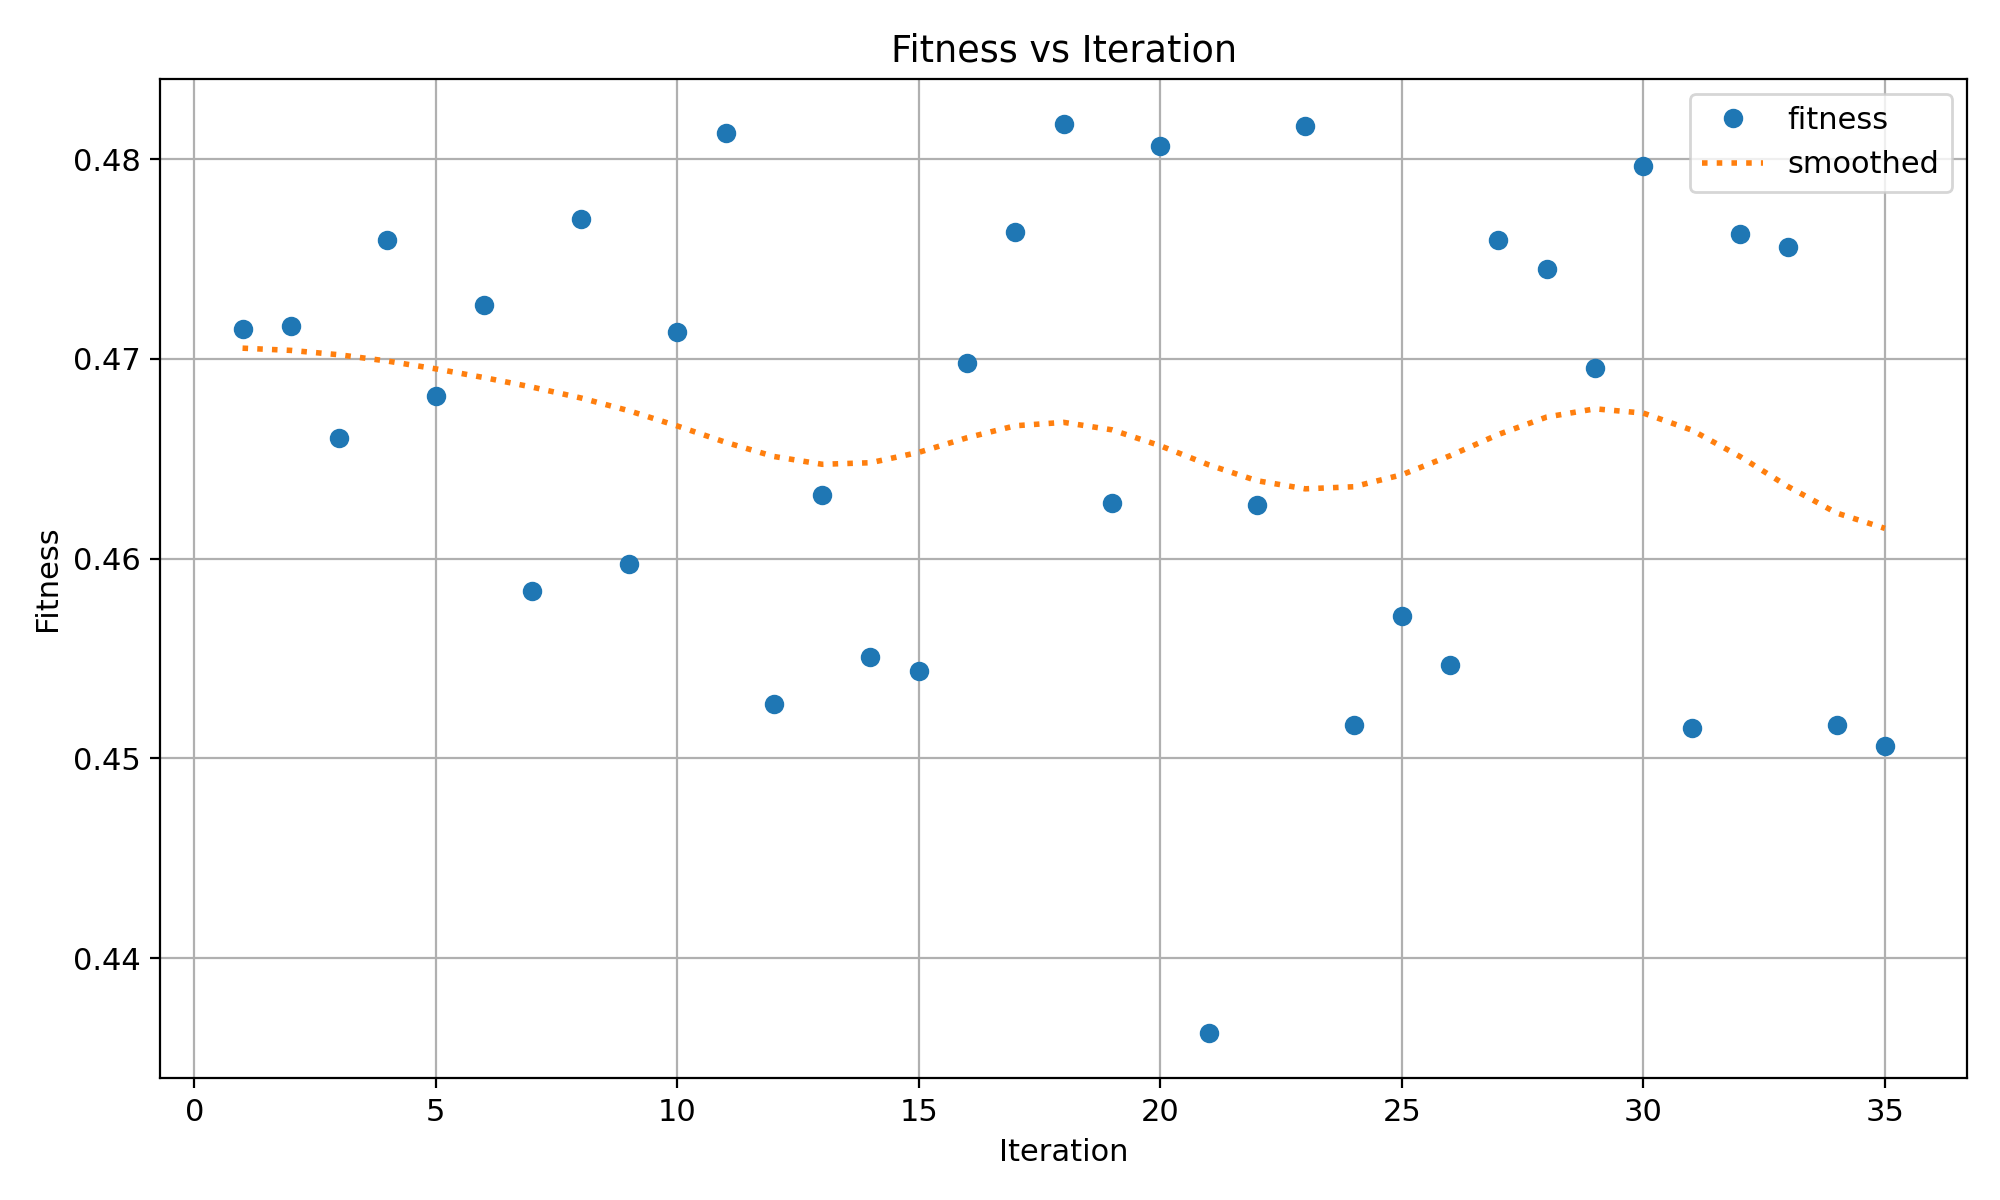

In [2]:
from IPython.display import Image

Image(filename='C:/Users/hjack/OneDrive/Documents/GitHub/Drone-Fire-Detection/runs/detect/yolo26n_tuned/tune_fitness.png', width=1000)

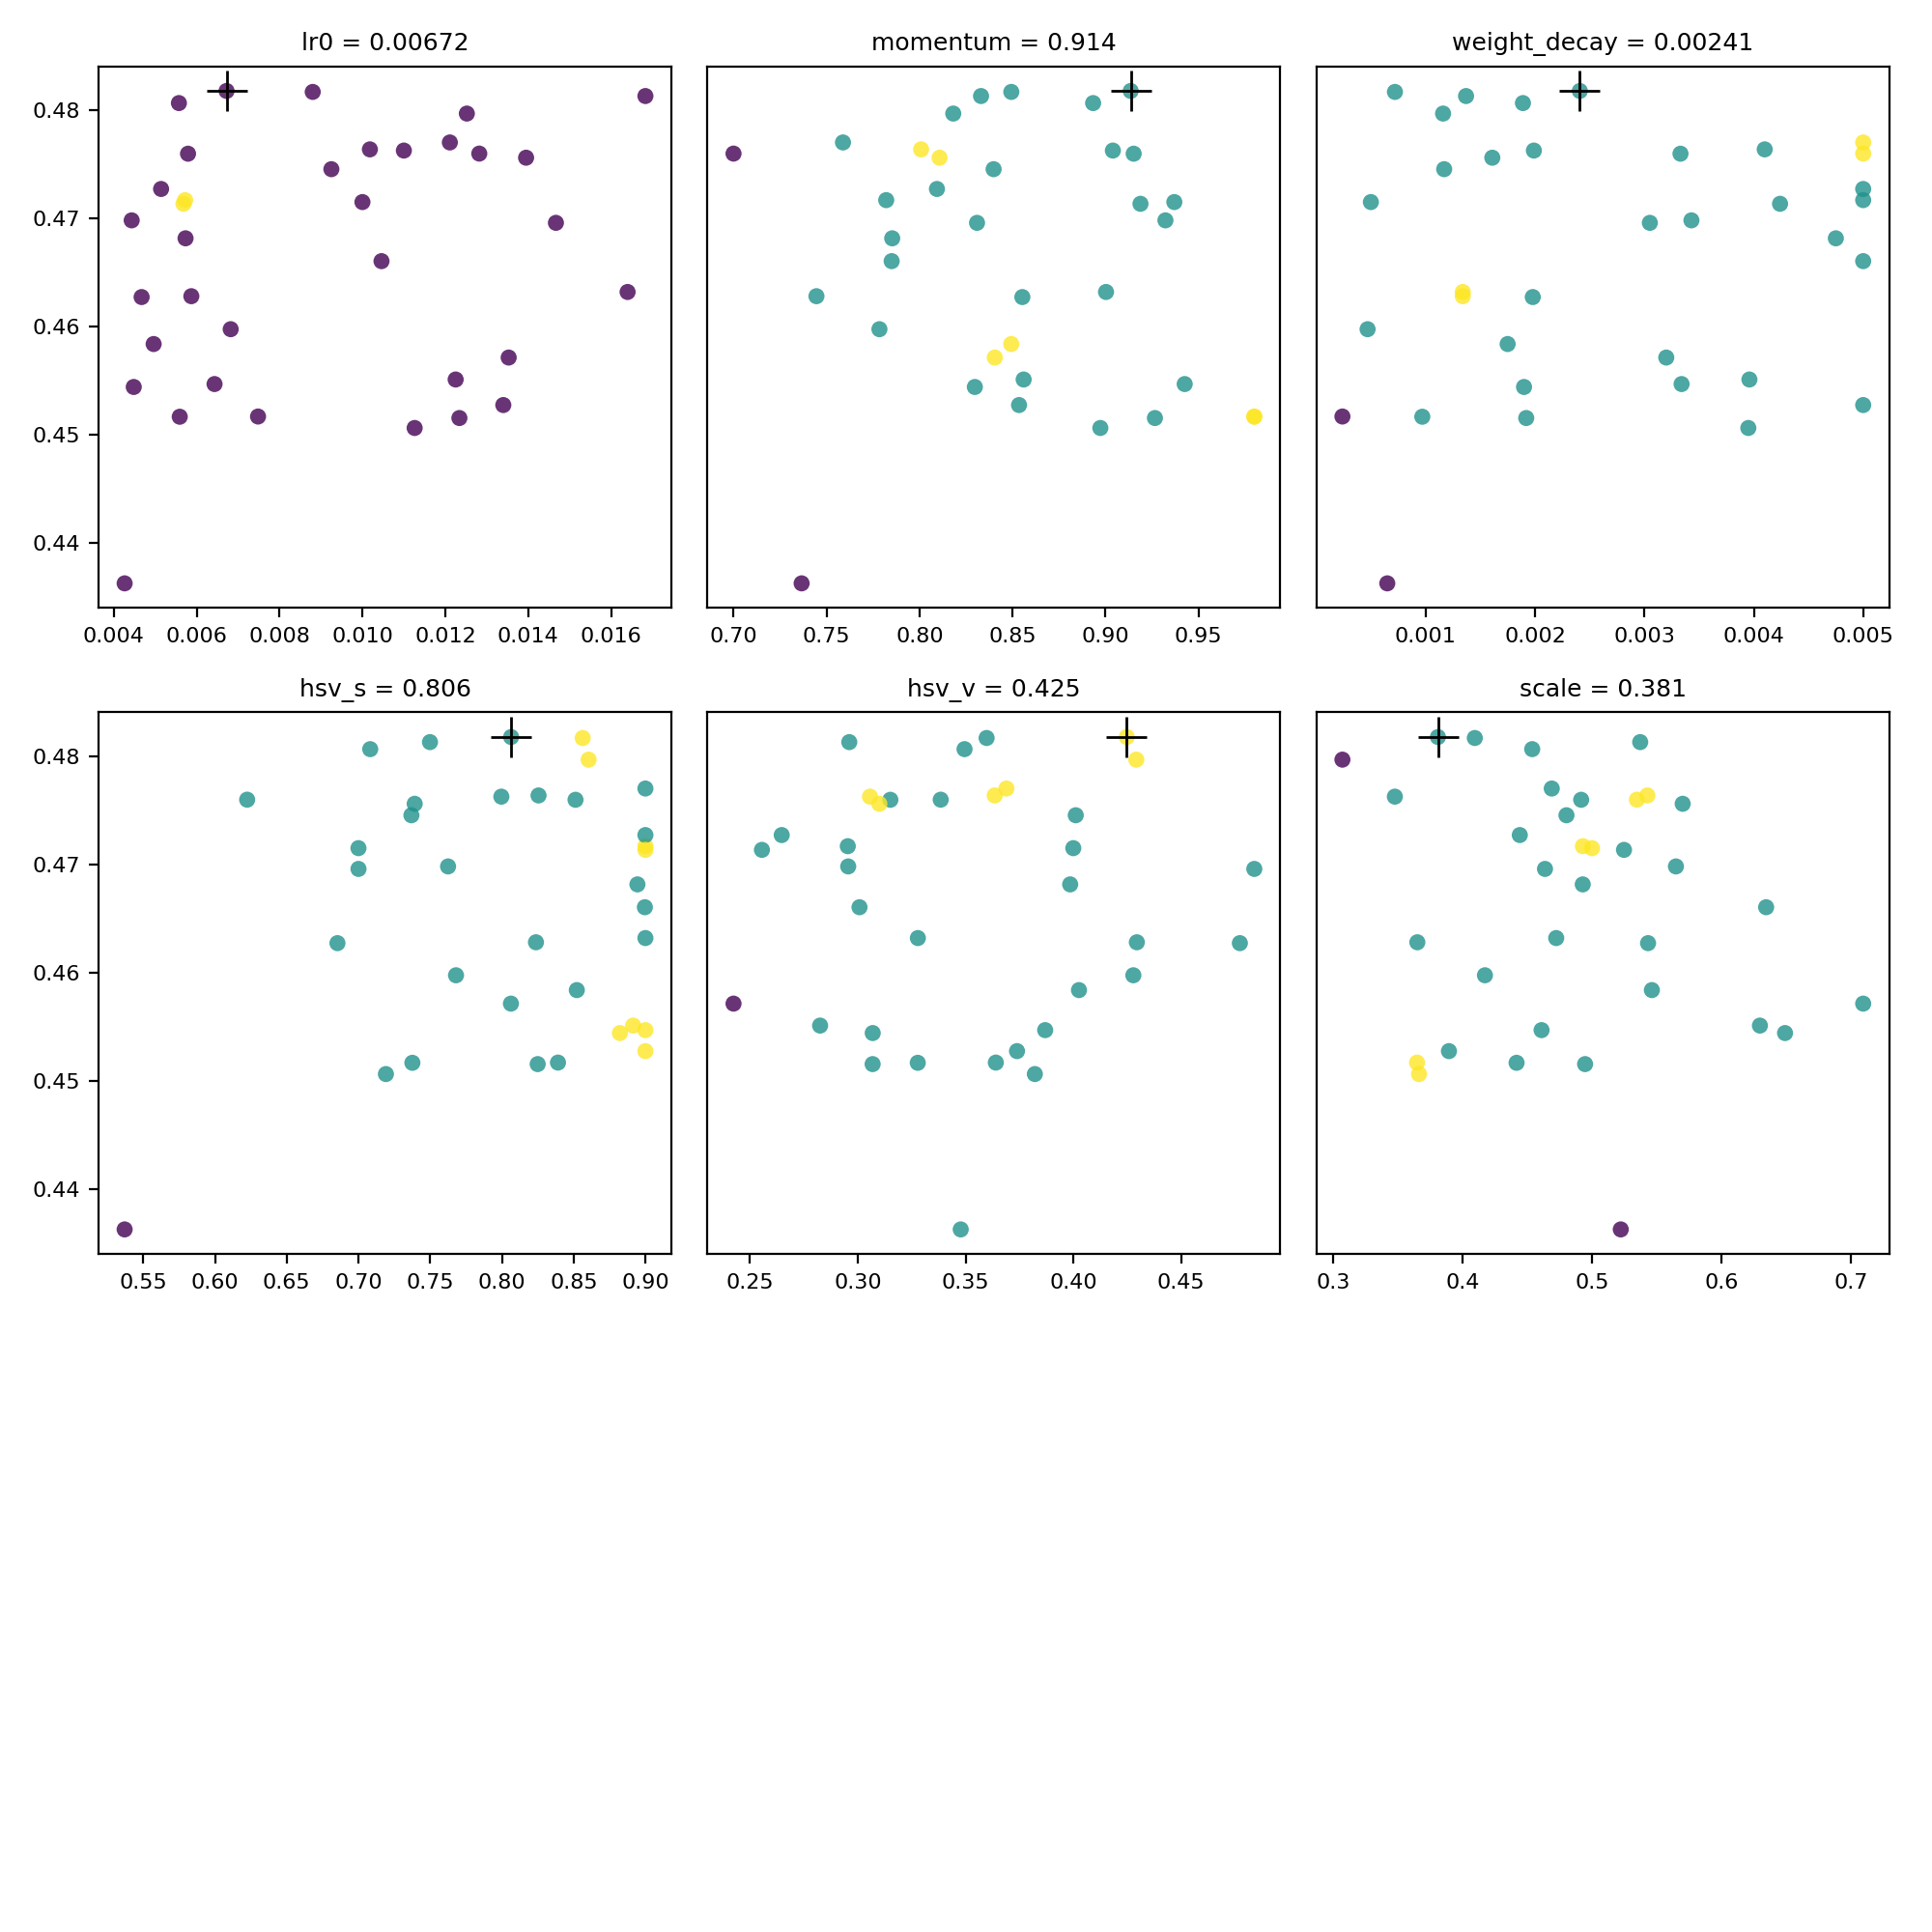

In [3]:
from IPython.display import Image

Image(filename='C:/Users/hjack/OneDrive/Documents/GitHub/Drone-Fire-Detection/runs/detect/yolo26n_tuned/tune_scatter_plots.png', width=1000)

#### YOLO26n Iteration #21

In [1]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLO26n model
model = YOLO("yolo26n.pt")

# Train the model on the Fire and Smoke dataset for 100 epochs
results = model.train(data="Fire and Smoke Dataset/data.yaml", epochs=100, imgsz=640, batch=-1, optimizer="SGD", lr0=0.00672, momentum=0.91355, weight_decay=0.00241, hsv_s=0.8064, hsv_v=0.42482, scale=0.38094, name="yolo26n_it21")

New https://pypi.org/project/ultralytics/8.4.40 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.31  Python-3.12.13 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Fire and Smoke Dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.8064, hsv_v=0.42482, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00672, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.91355, mosaic=1.0, multi_

#### Results For YOLO26n Iteration #21

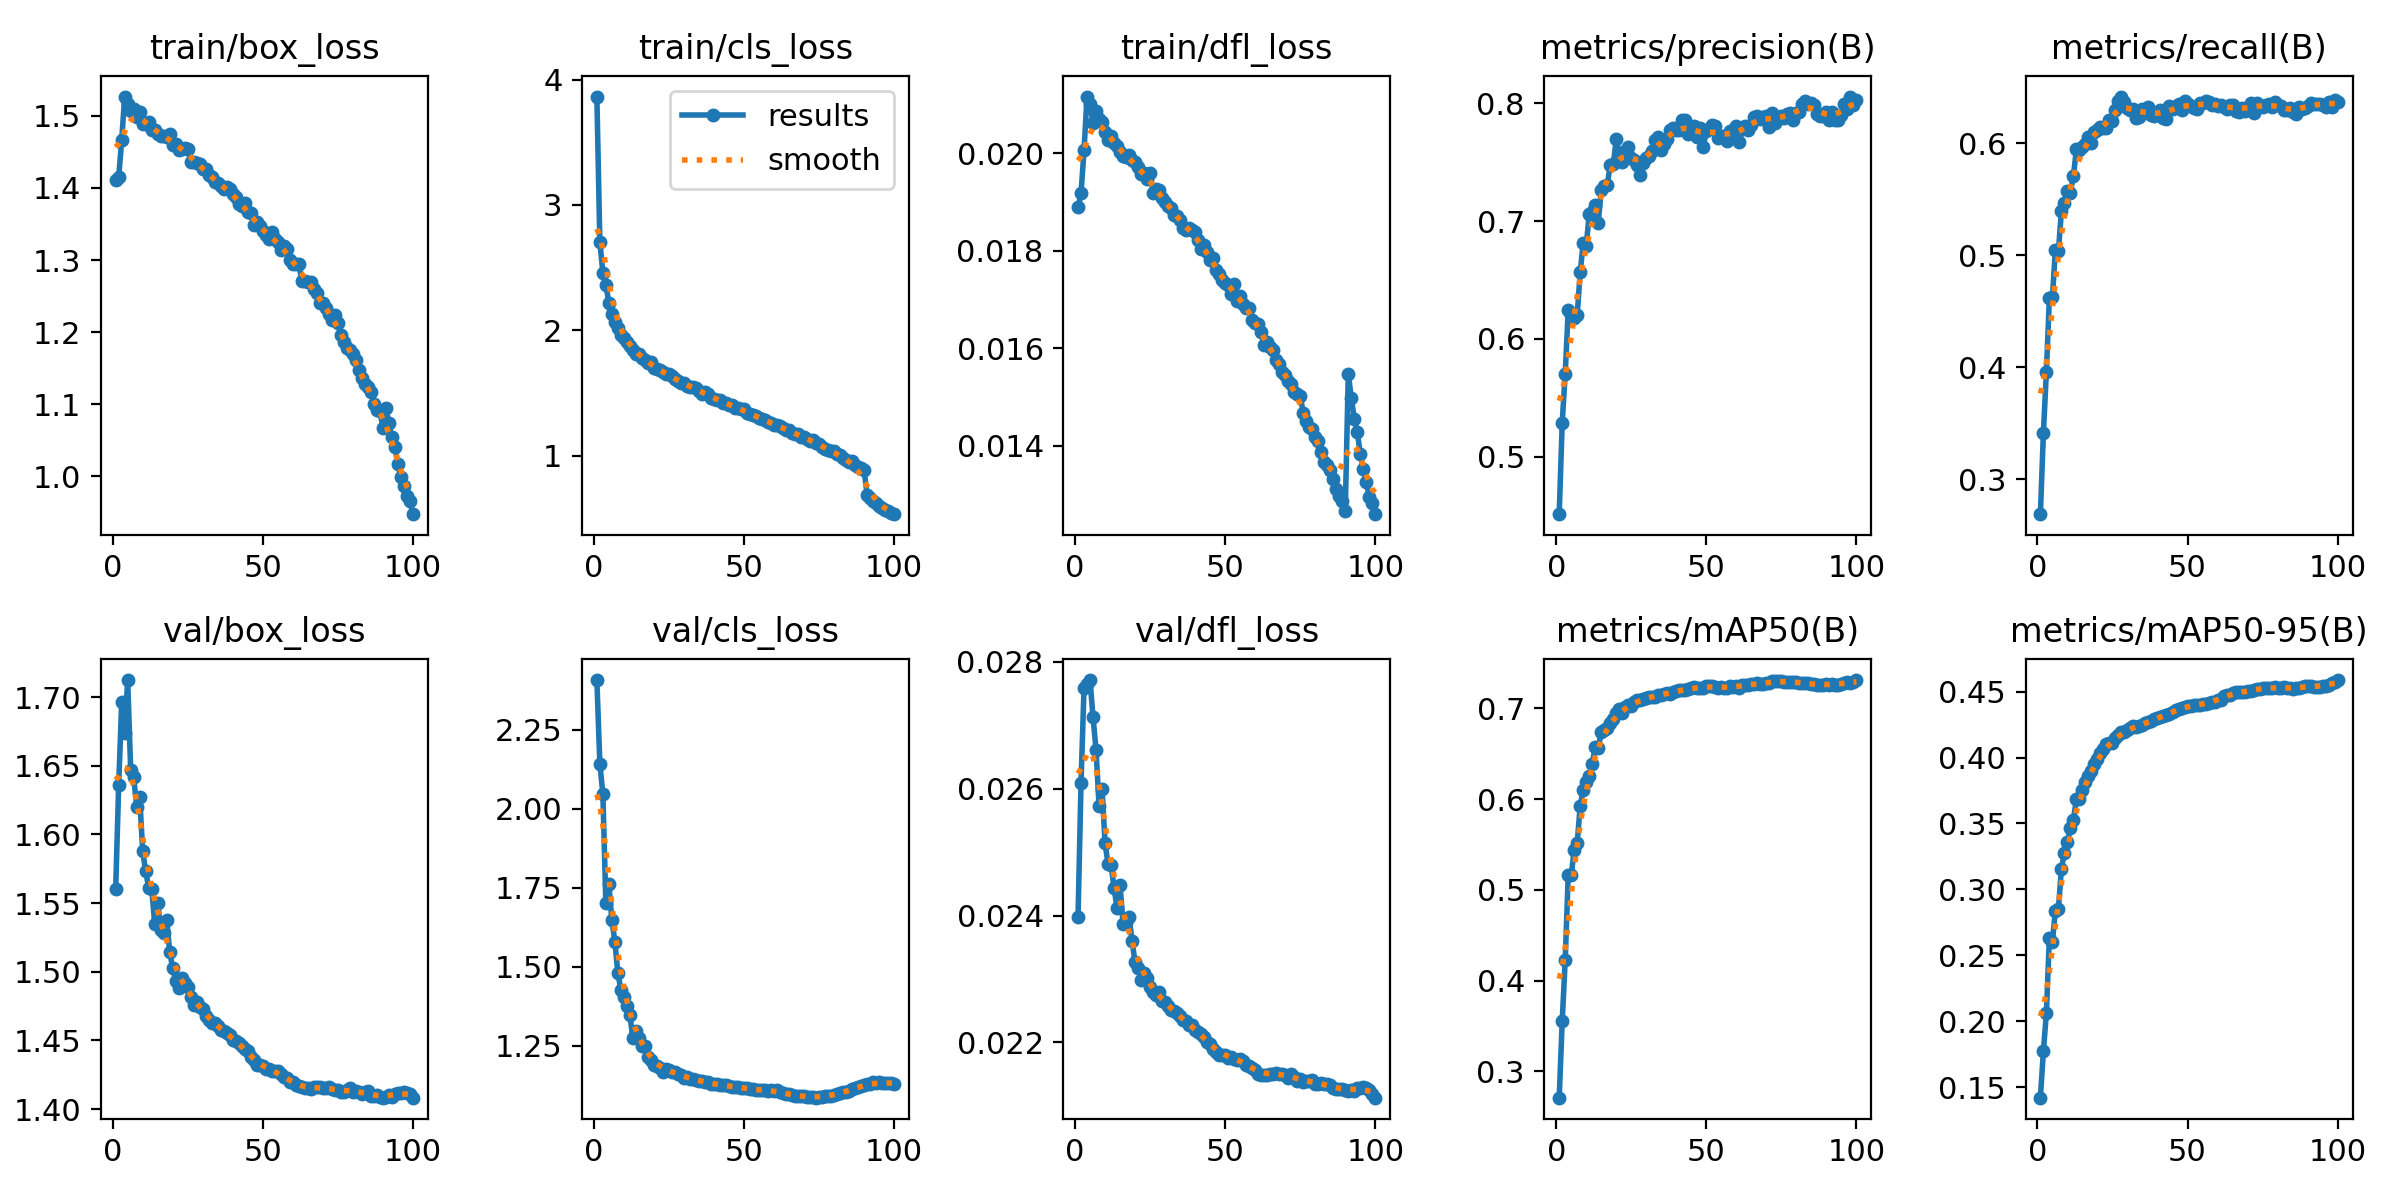

In [2]:
from IPython.display import Image

Image(filename='C:/Users/hjack/OneDrive/Documents/GitHub/Drone-Fire-Detection/runs/detect/yolo26n_it21/results.png', width=1000)

#### YOLO26n Iteration #27

In [3]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLO26n model
model = YOLO("yolo26n.pt")

# Train the model on the Fire and Smoke dataset for 100 epochs
results = model.train(data="Fire and Smoke Dataset/data.yaml", epochs=100, imgsz=640, batch=-1, optimizer="SGD", lr0=0.0088, momentum=0.84935, weight_decay=0.00072, hsv_s=0.85628, hsv_v=0.35978, scale=0.40943, name="yolo26n_it27")

New https://pypi.org/project/ultralytics/8.4.40 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.31  Python-3.12.13 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Fire and Smoke Dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.85628, hsv_v=0.35978, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0088, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.84935, mosaic=1.0, multi_

#### Results For YOLO26n Iteration #27

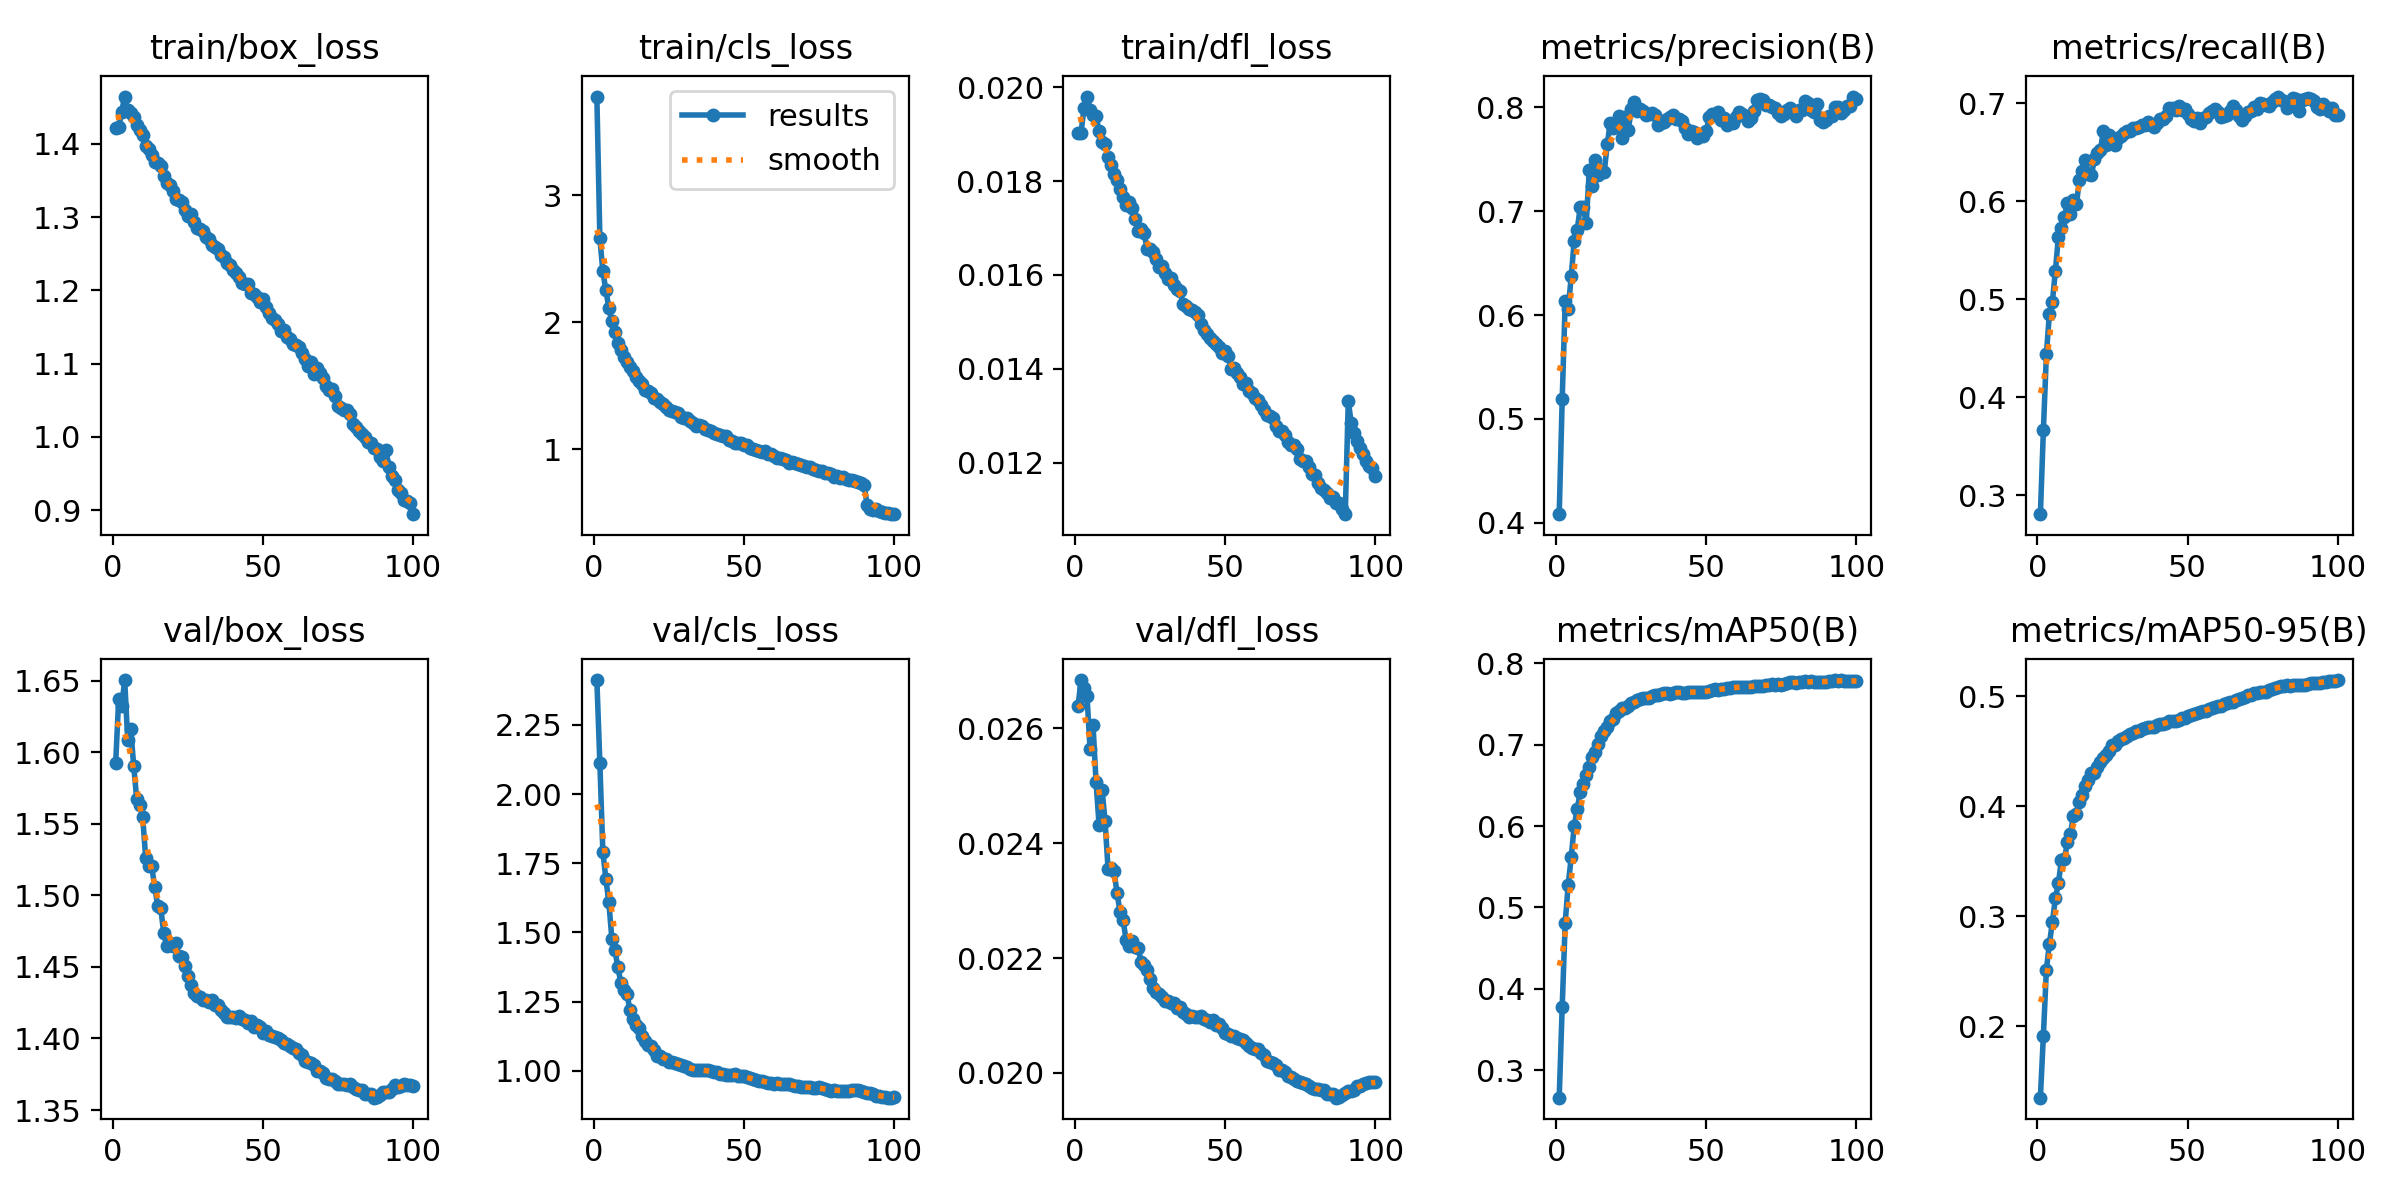

In [4]:
from IPython.display import Image

Image(filename='C:/Users/hjack/OneDrive/Documents/GitHub/Drone-Fire-Detection/runs/detect/yolo26n_it27/results.png', width=1000)

#### YOLO26n Iteration #13

In [5]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLO26n model
model = YOLO("yolo26n.pt")

# Train the model on the Fire and Smoke dataset for 100 epochs
results = model.train(data="Fire and Smoke Dataset/data.yaml", epochs=100, imgsz=640, batch=-1, optimizer="SGD", lr0=0.01683, momentum=0.83308, weight_decay=0.00137, hsv_s=0.74985, hsv_v=0.29605, scale=0.53722, name="yolo26n_it13")

New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.31  Python-3.12.13 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Fire and Smoke Dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.74985, hsv_v=0.29605, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01683, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.83308, mosaic=1.0, multi

#### Results For YOLO26n Iteration #13

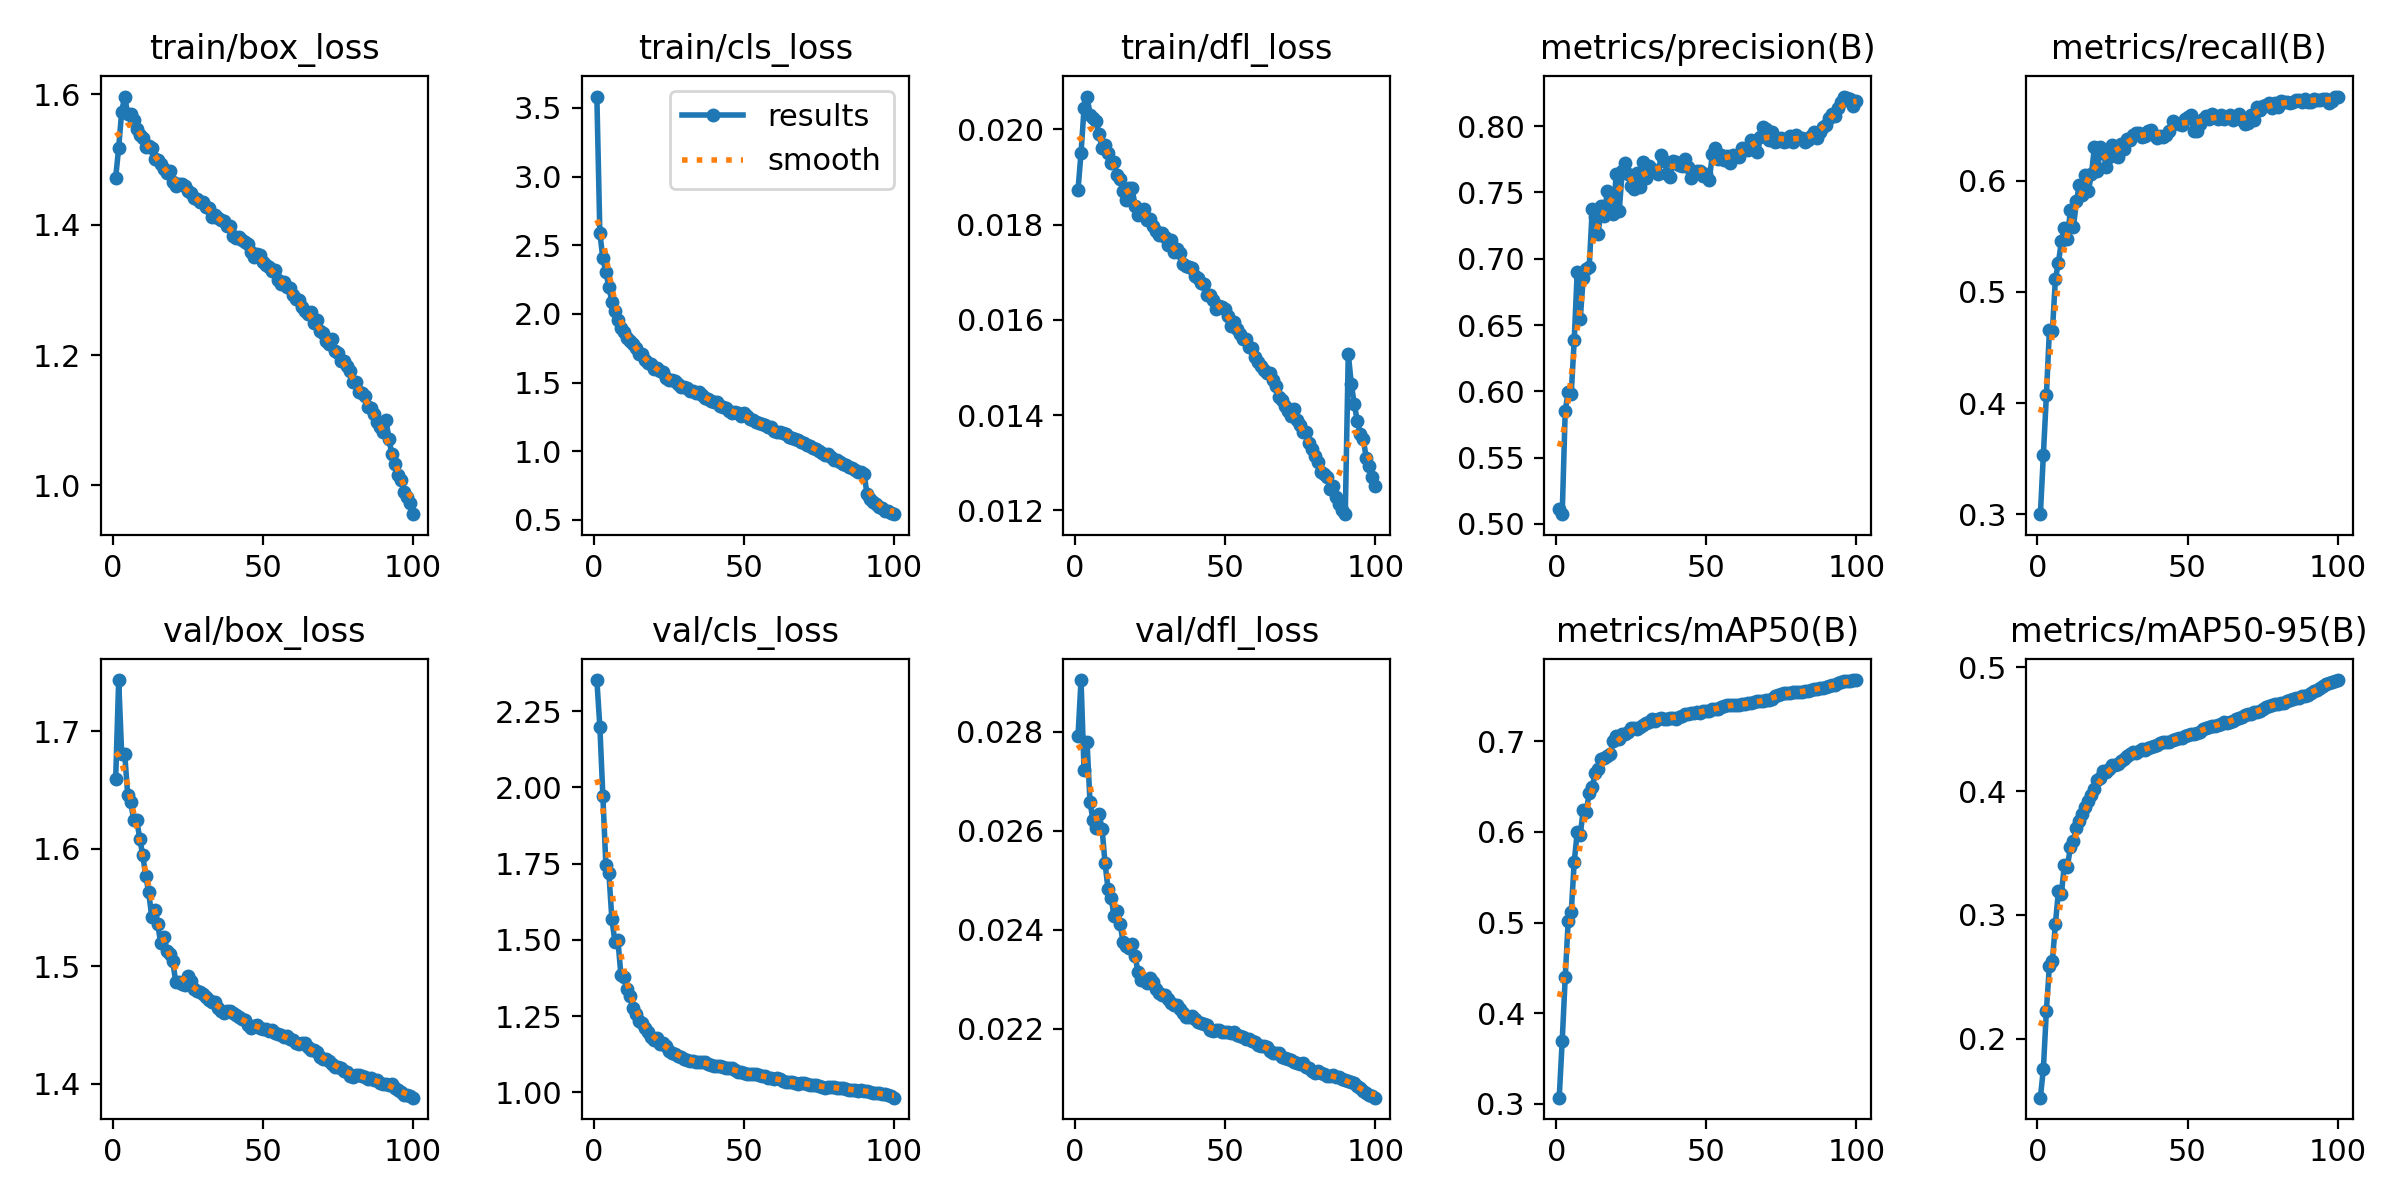

In [6]:
from IPython.display import Image

Image(filename='C:/Users/hjack/OneDrive/Documents/GitHub/Drone-Fire-Detection/runs/detect/yolo26n_it13/results.png', width=1000)

#### YOLO26n Iteration #23

In [7]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLO26n model
model = YOLO("yolo26n.pt")

# Train the model on the Fire and Smoke dataset for 100 epochs
results = model.train(data="Fire and Smoke Dataset/data.yaml", epochs=100, imgsz=640, batch=-1, optimizer="SGD", lr0=0.00557, momentum=0.89334, weight_decay=0.00189, hsv_s=0.7082, hsv_v=0.34954, scale=0.45378, name="yolo26n_it23")

New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.31  Python-3.12.13 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Fire and Smoke Dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7082, hsv_v=0.34954, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00557, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.89334, mosaic=1.0, multi_

#### Results For YOLO26n Iteration #23

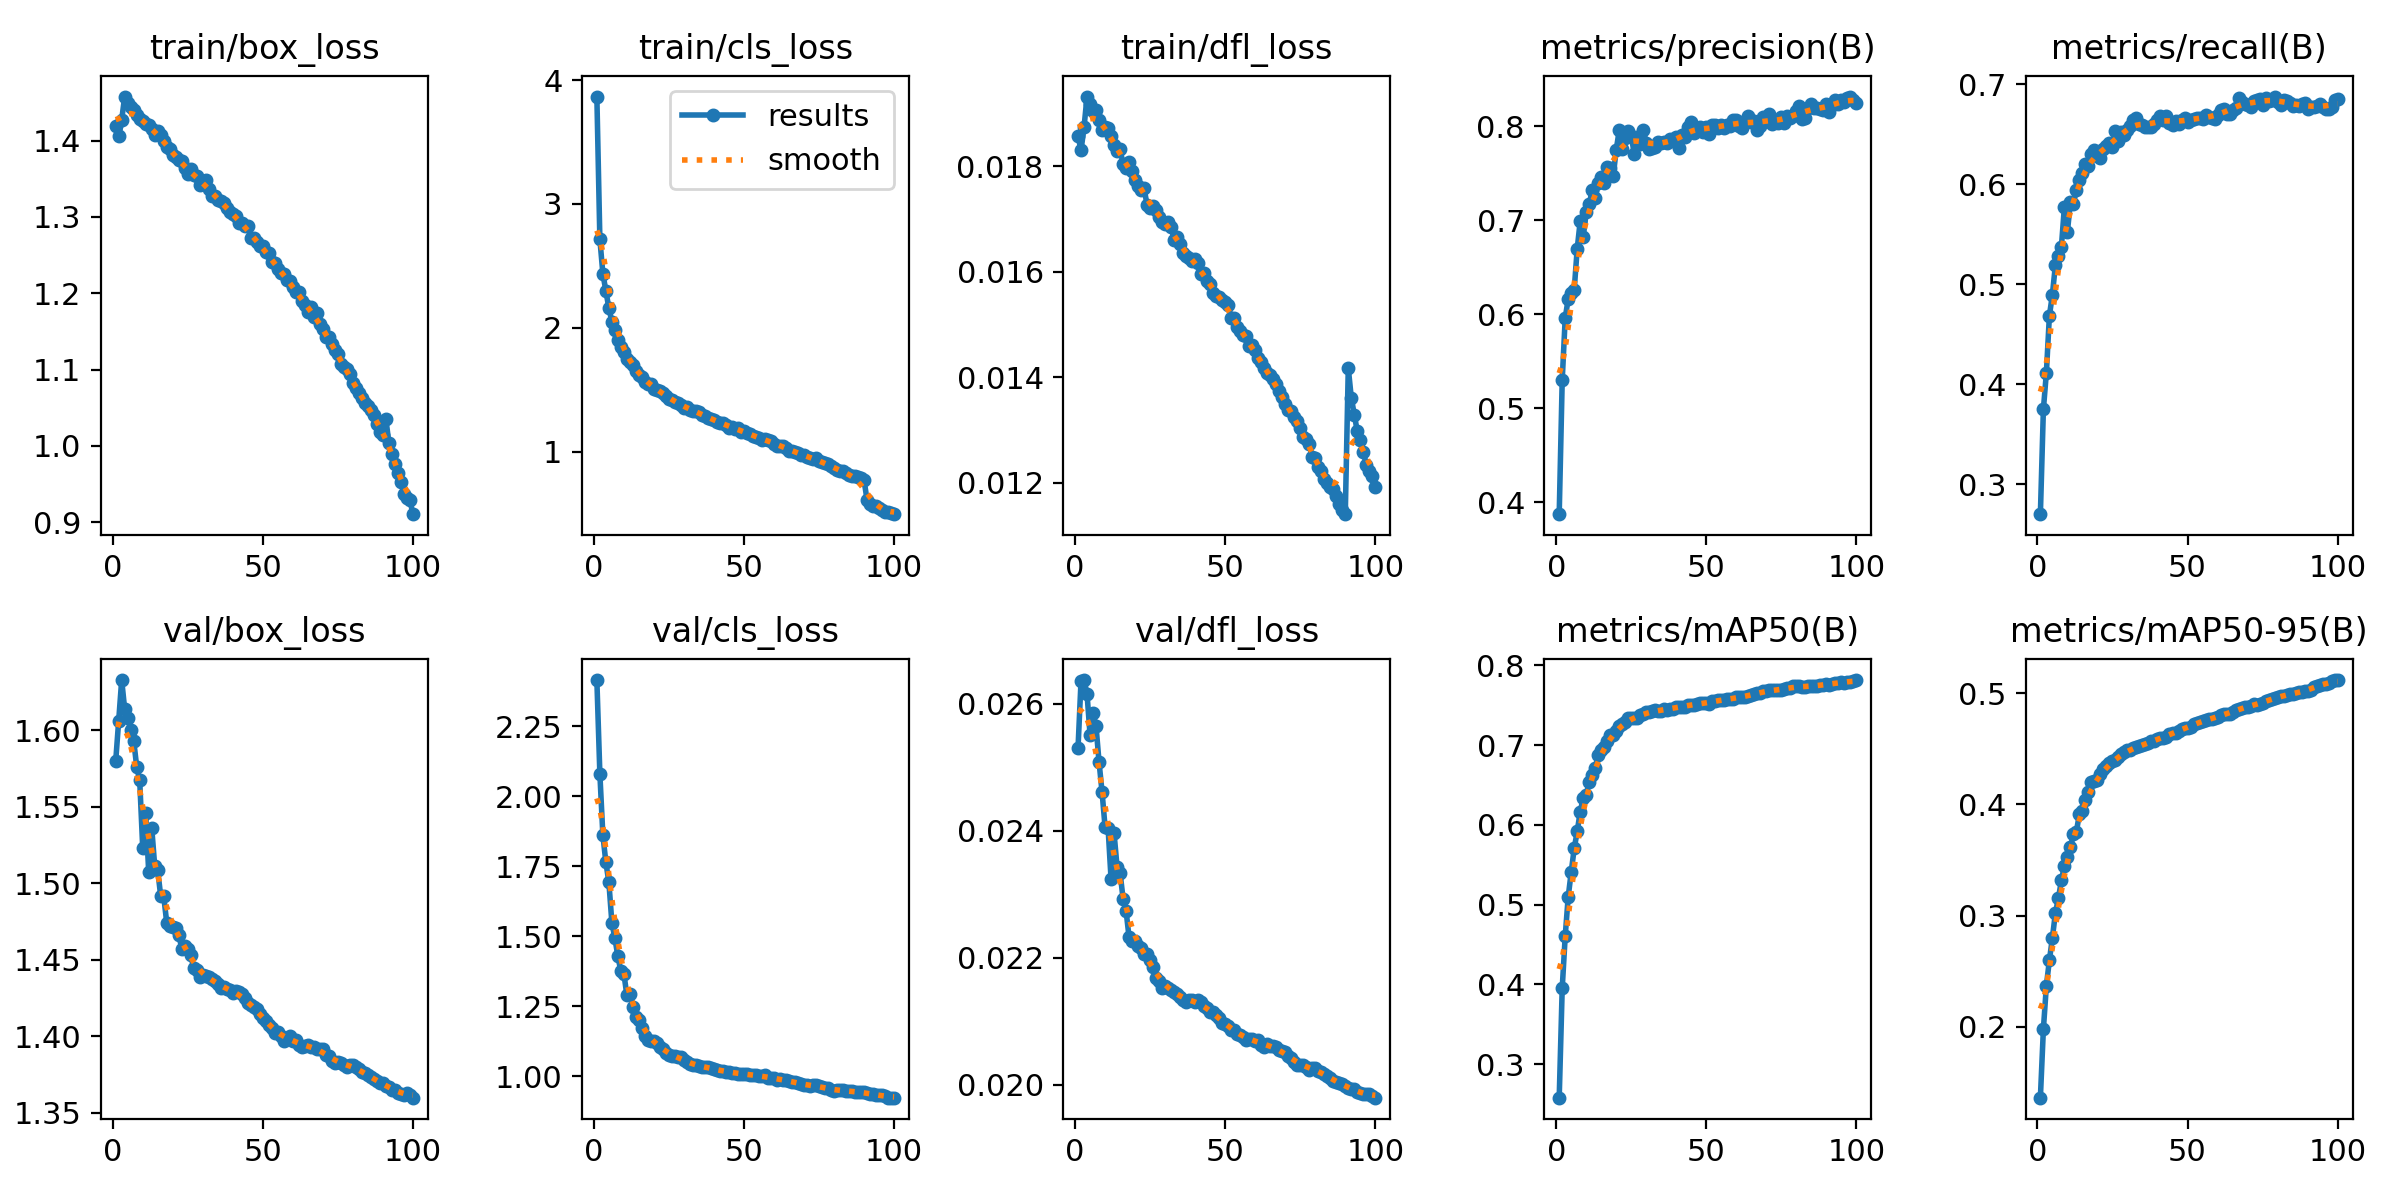

In [8]:
from IPython.display import Image

Image(filename='C:/Users/hjack/OneDrive/Documents/GitHub/Drone-Fire-Detection/runs/detect/yolo26n_it23/results.png', width=1000)

#### YOLO26n Iteration #35

In [9]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLO26n model
model = YOLO("yolo26n.pt")

# Train the model on the Fire and Smoke dataset for 100 epochs
results = model.train(data="Fire and Smoke Dataset/data.yaml", epochs=100, imgsz=640, batch=-1, optimizer="SGD", lr0=0.01252, momentum=0.81814, weight_decay=0.00116, hsv_s=0.86042, hsv_v=0.42924, scale=0.30714, name="yolo26n_it35")

New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.31  Python-3.12.13 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Fire and Smoke Dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.86042, hsv_v=0.42924, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01252, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.81814, mosaic=1.0, multi

#### Results For YOLO26n Iteration #35

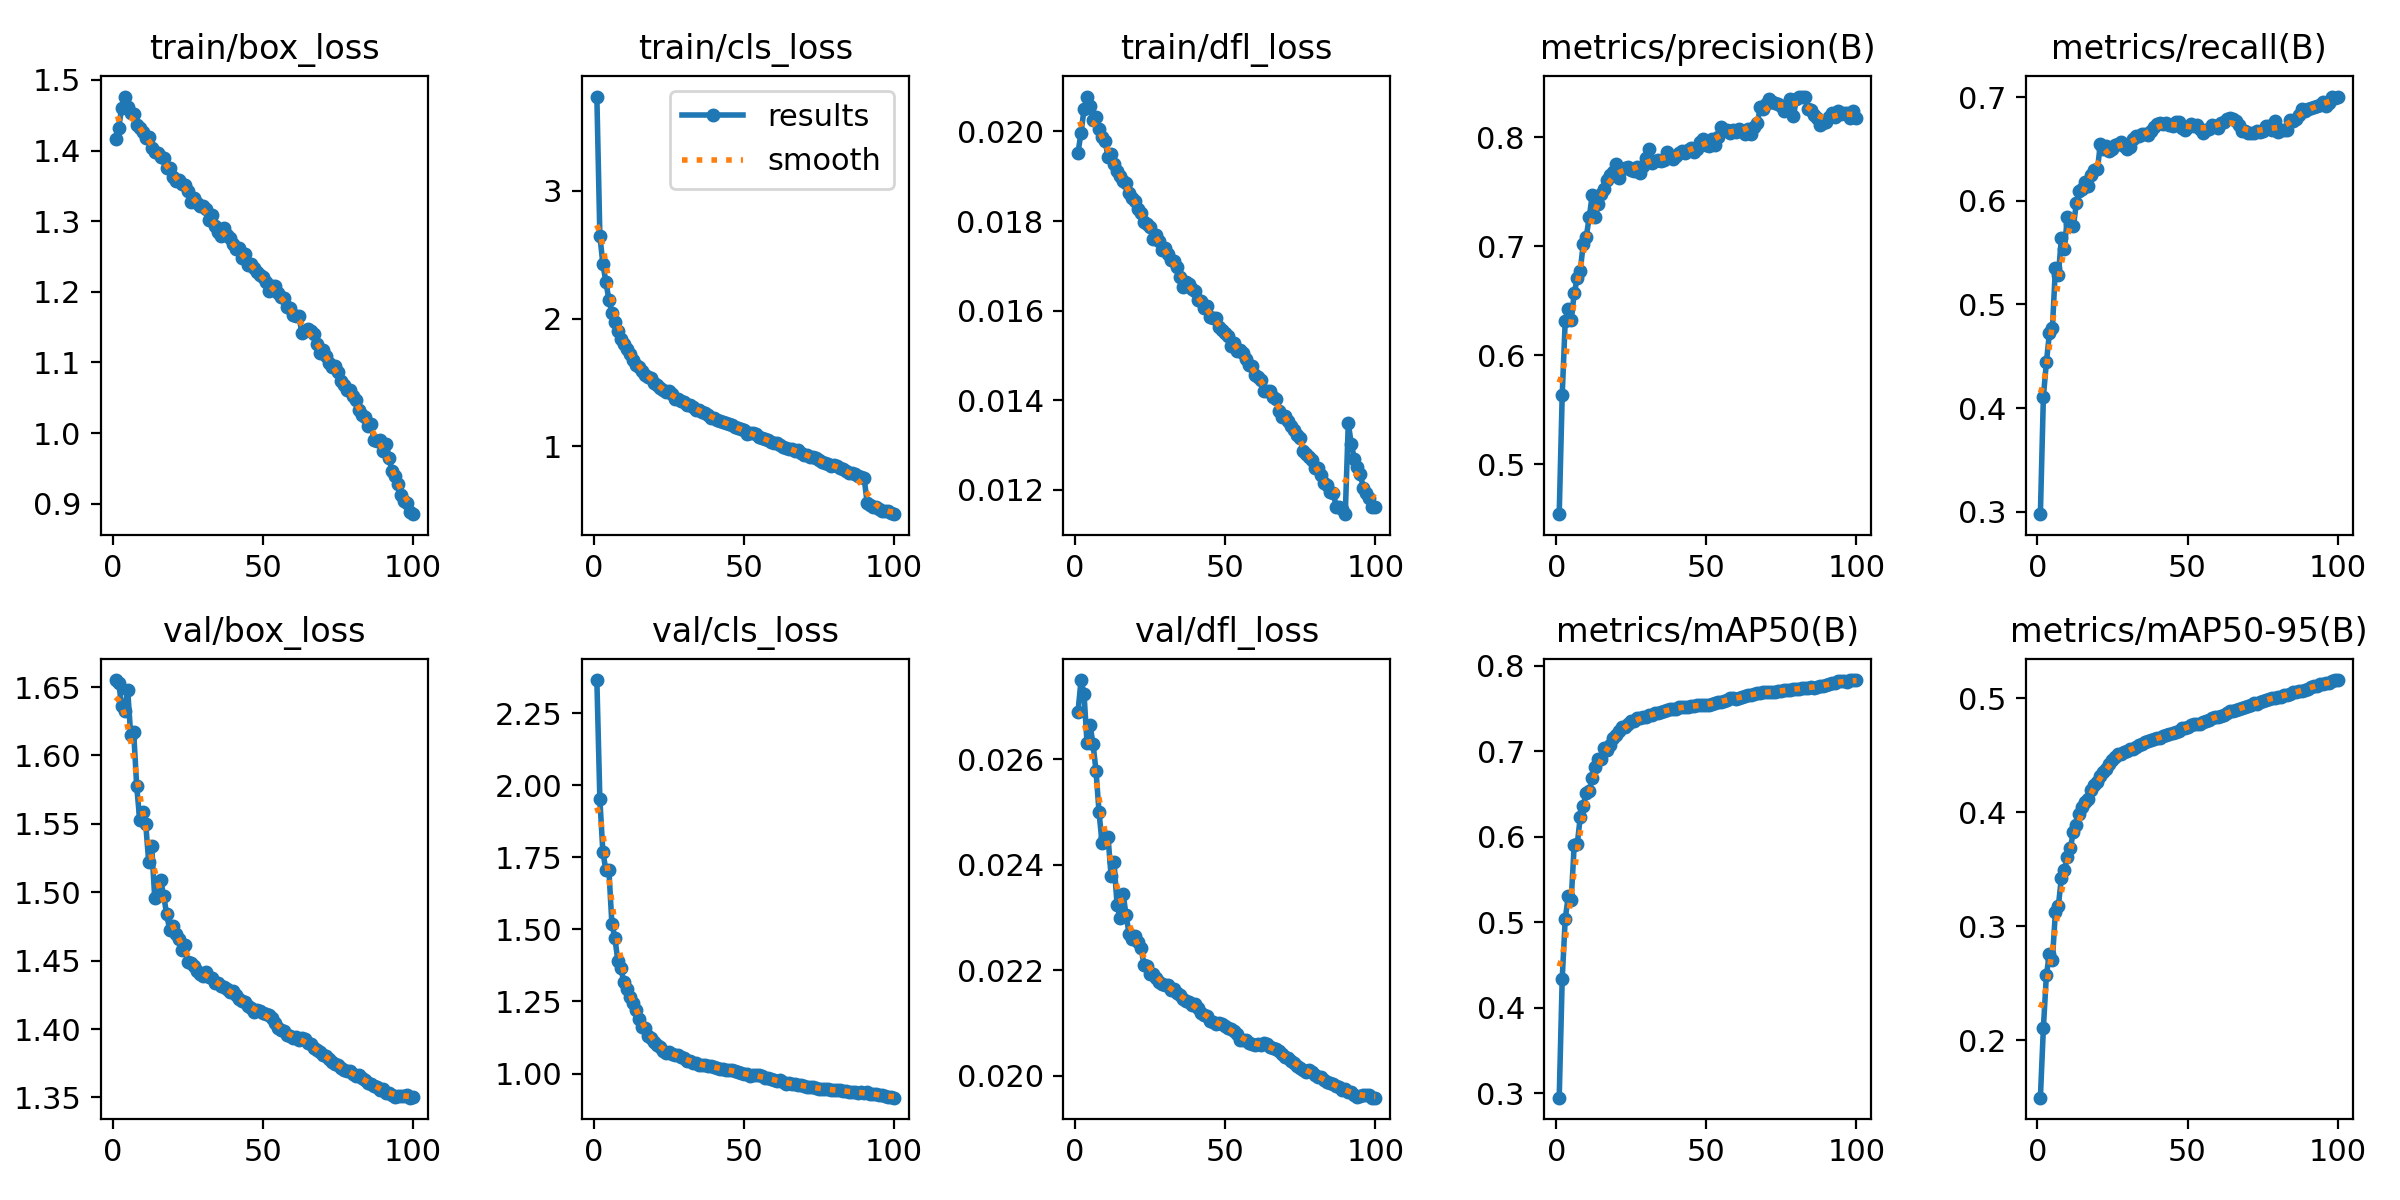

In [10]:
from IPython.display import Image

Image(filename='C:/Users/hjack/OneDrive/Documents/GitHub/Drone-Fire-Detection/runs/detect/yolo26n_it35/results.png', width=1000)

### Model Evaluation

In [12]:
from ultralytics import YOLO

model = YOLO("runs/detect/yolo26n_it35/weights/best.pt")

metrics = model.val(data="Fire and Smoke Dataset/data.yaml", split="test")

Ultralytics 8.4.31  Python-3.12.13 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 366.4195.2 MB/s, size: 31.1 KB)
val: Scanning C:\Users\hjack\OneDrive\Documents\GitHub\Drone-Fire-Detection\Fire and Smoke Dataset\test\labels.cache... 2255 images, 378 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2255/2255  0.0s
WARNING Box and segment counts should be equal, but got len(segments) = 143, len(boxes) = 2813. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 141/141 18.0it/s 7.8s0.1s
                   all       2255       2813       0.83      0.676      0.753      0.495
                  fire       1481       2095      0.

### Convert Model to NCNN

In [1]:
from ultralytics import YOLO

# Load the YOLO26 model
model = YOLO("runs/detect/yolo26n_it35/weights/best.pt")

# Export the model to NCNN format
model.export(format="ncnn")

Ultralytics 8.4.31  Python-3.12.13 torch-2.11.0+cu130 CPU (AMD Ryzen 7 9800X3D 8-Core Processor)
WARNING NCNN export does not support end2end models, disabling end2end branch.
YOLO26n summary (fused): 146 layers, 2,495,084 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from 'runs\detect\yolo26n_it35\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (5.1 MB)
requirements: Ultralytics requirement ['ncnn'] not found, attempting AutoUpdate...
   ---------------------------------------- 0.0/3.8 MB ? eta -:--:--
   ------------------- -------------------- 1.8/3.8 MB 10.1 MB/s eta 0:00:01
   ---------------------------------------- 3.8/3.8 MB 11.2 MB/s  0:00:00

requirements: AutoUpdate success  1.6s
WARNING requirements: Restart runtime or rerun command for updates to take effect

requirements: Ultralytics requirement ['pnnx'] not found, attempting AutoUpdate...
   ---------------------------------------- 0.0/18.3 MB ? eta -:--:--
   ---- ------

'runs\\detect\\yolo26n_it35\\weights\\best_ncnn_model'